# DDPM on two moons (§12.3, Algorithm 21)

$$x_t=\sqrt{\bar\alpha_t}\,x_0+\sqrt{1-\bar\alpha_t}\,\varepsilon,\qquad
\min_\theta\,\mathbb{E}\|\varepsilon-\varepsilon_\theta(x_t,t)\|^2,\qquad
x_{t-1}=\tfrac{1}{\sqrt{\alpha_t}}\big(x_t-\tfrac{\beta_t}{\sqrt{1-\bar\alpha_t}}\varepsilon_\theta\big)+\sigma_t z$$

In [1]:
import math
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)

def sample_moons(n):
    n1, n2 = n // 2, n - n // 2
    t1 = torch.rand(n1) * math.pi
    t2 = torch.rand(n2) * math.pi
    x1 = torch.stack([torch.cos(t1), torch.sin(t1)], dim=1)
    x2 = torch.stack([1 - torch.cos(t2), -torch.sin(t2) + 0.5], dim=1)
    x = torch.cat([x1, x2]) + 0.05 * torch.randn(n, 2)
    return (x - x.mean(0)) / x.std(0)

data = sample_moons(4096)

In [2]:
T = 200
beta = torch.linspace(1e-4, 0.02, T)
alpha = 1.0 - beta
alpha_bar = torch.cumprod(alpha, dim=0)


class EpsNet(nn.Module):
    def __init__(self, dim=2, t_dim=32, width=128):
        super().__init__()
        self.t_dim = t_dim
        self.net = nn.Sequential(
            nn.Linear(dim + t_dim, width), nn.SiLU(),
            nn.Linear(width, width), nn.SiLU(),
            nn.Linear(width, width), nn.SiLU(),
            nn.Linear(width, dim),
        )

    def time_embed(self, t):
        half = self.t_dim // 2
        freqs = torch.exp(-math.log(1000) * torch.arange(half) / half)
        angles = t[:, None].float() * freqs[None, :]
        return torch.cat([torch.sin(angles), torch.cos(angles)], dim=1)

    def forward(self, x, t):
        return self.net(torch.cat([x, self.time_embed(t)], dim=1))

In [3]:
model = EpsNet()
opt = torch.optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(3001):
    x0 = data[torch.randint(0, len(data), (256,))]
    t = torch.randint(0, T, (256,))
    eps = torch.randn_like(x0)
    ab = alpha_bar[t][:, None]
    xt = ab.sqrt() * x0 + (1 - ab).sqrt() * eps

    loss = ((eps - model(xt, t)) ** 2).mean()
    opt.zero_grad()
    loss.backward()
    opt.step()
    if epoch % 500 == 0:
        print(f"epoch {epoch:5d}   loss = {loss.item():.4f}")

epoch     0   loss = 0.9765


epoch   500   loss = 0.5256


epoch  1000   loss = 0.5558


epoch  1500   loss = 0.5013


epoch  2000   loss = 0.5227


epoch  2500   loss = 0.4960


epoch  3000   loss = 0.4213


In [4]:
@torch.no_grad()
def sample(model, n=2000, keep_steps=()):
    x = torch.randn(n, 2)
    snaps = {}
    for i in reversed(range(T)):
        if i in keep_steps:
            snaps[i] = x.clone()
        t = torch.full((n,), i, dtype=torch.long)
        eps_hat = model(x, t)
        mean = (x - beta[i] / (1 - alpha_bar[i]).sqrt() * eps_hat) / alpha[i].sqrt()
        x = mean + beta[i].sqrt() * torch.randn_like(x) if i > 0 else mean
    return x, snaps


gen, snaps = sample(model, keep_steps=(199, 100, 50))

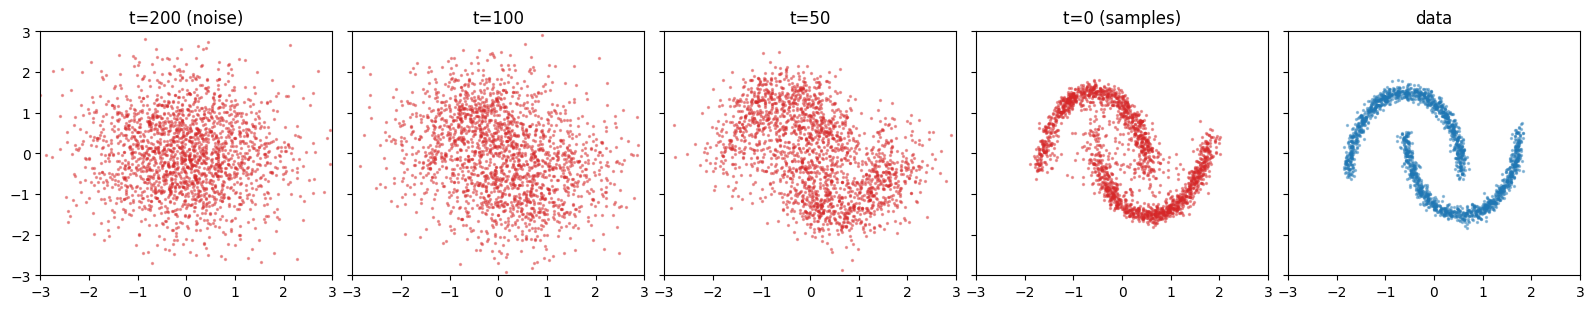

data mean/std: [0.0, -0.0] [1.0, 1.0]
gen  mean/std: [0.0989999994635582, -0.04899999871850014] [0.9470000267028809, 1.0190000534057617]


In [5]:
fig, axes = plt.subplots(1, 5, figsize=(16, 3.2), sharex=True, sharey=True)
panels = [("t=200 (noise)", snaps[199]), ("t=100", snaps[100]), ("t=50", snaps[50]),
          ("t=0 (samples)", gen), ("data", data[torch.randperm(len(data))[:2000]])]
for ax, (title, pts) in zip(axes, panels):
    ax.scatter(pts[:, 0], pts[:, 1], s=2, alpha=0.4,
               color="tab:blue" if title == "data" else "tab:red")
    ax.set_title(title); ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
plt.tight_layout(); plt.show()

print("data mean/std:", data.mean(0).round(decimals=3).tolist(), data.std(0).round(decimals=3).tolist())
print("gen  mean/std:", gen.mean(0).round(decimals=3).tolist(), gen.std(0).round(decimals=3).tolist())